Link dataset: https://www.kaggle.com/datasets/fedesoriano/traffic-prediction-dataset

In questo Dataset sono presenti   colonne che descrivono rispettivamente ID, Junction (incrocio), orario, data, e numero di auto che è il valore che voglio stimare. Quindi in base alla posizione dell'utente (a che incrocio si trova), all'orario e al giorno (se festivo o lavorativo) stimare se troverà traffico o meno.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('archive/traffic.csv')

print(df.head())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


In [2]:


# Convertiamo la colonna DateTime in un formato che Python capisce
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek # 0=Lunedì, 6=Domenica

df_final = df.drop(['DateTime', 'ID'], axis=1)

display(df_final.head(10))

,Junction,Vehicles,Year,Month,Day,Hour,DayOfWeek
0,1,15,2015,11,1,0,6
1,2,6,2015,11,1,0,6
2,3,9,2015,11,1,0,6
3,3,7,2015,11,1,1,6
4,1,13,2015,11,1,1,6
5,2,6,2015,11,1,1,6
6,2,5,2015,11,1,2,6
7,1,10,2015,11,1,2,6
8,3,5,2015,11,1,2,6
9,2,6,2015,11,1,3,6


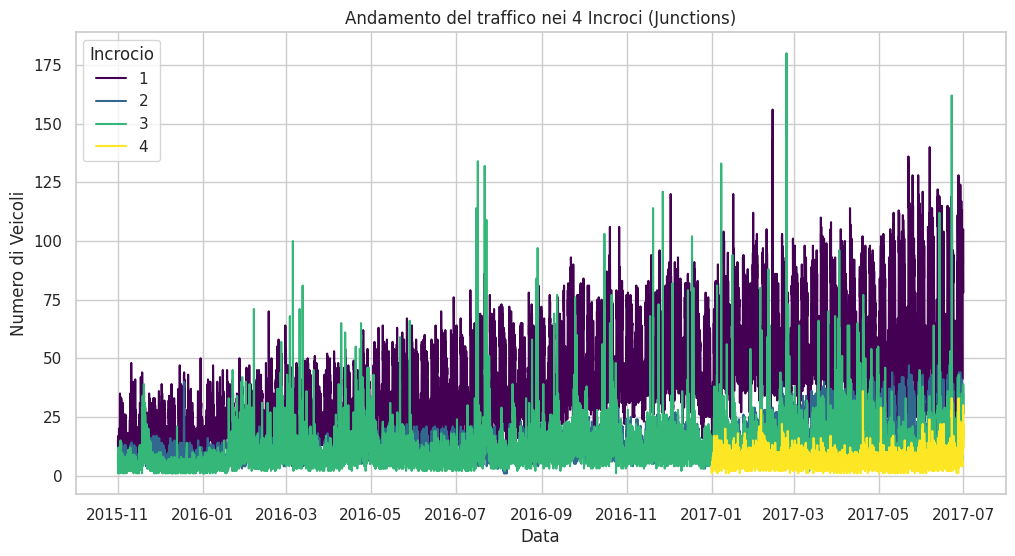

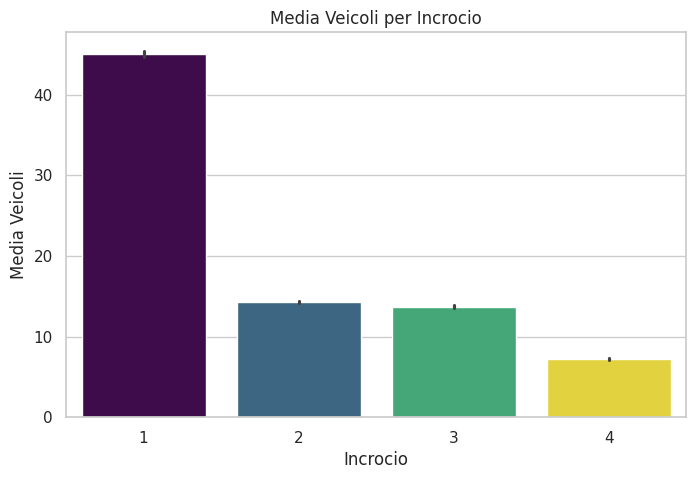

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Creiamo un grafico che mostra l'andamento dei veicoli nel tempo per ogni incrocio
sns.lineplot(data=df, x='DateTime', y='Vehicles', hue='Junction', palette='viridis')

plt.title('Andamento del traffico nei 4 Incroci (Junctions)')
plt.xlabel('Data')
plt.ylabel('Numero di Veicoli')
plt.legend(title='Incrocio')
plt.show()

# Facciamo anche un grafico a barre per vedere la media di veicoli per incrocio
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Junction', y='Vehicles', hue="Junction", palette='viridis', legend=False)
#plt.xticks(x, df['Junction'].unique())
plt.title('Media Veicoli per Incrocio')
plt.xlabel('Incrocio')
plt.ylabel('Media Veicoli')
plt.show()

In [4]:
# 1. Definiamo X e y
X = df_final.drop(['Vehicles'], axis=1)
y = df_final['Vehicles']

# 2. Calcoliamo l'indice per lo split cronologico (70% train, 15% validation, 15% test)
n = len(df_final)
train_index = int(n * 0.7)
val_index = int(n * 0.85)

# 3. Creiamo i set di Training e Test
X_train = X.iloc[:train_index]
y_train = y.iloc[:train_index]
X_val = X.iloc[train_index:val_index] # validation set per allenare Optuna
y_val = y.iloc[train_index:val_index]
X_test = X.iloc[val_index:]
y_test = y.iloc[val_index:]

print(f"--- SPLIT CRONOLOGICO EFFETTUATO ---")
print(f"Dati di Allenamento (70%): {X_train.shape[0]} righe")
print(f"Dati di Validazione (15%): {X_val.shape[0]} righe")
print(f"Dati di Test (15%): {X_test.shape[0]} righe")

# Verifica rapida: l'ultima riga del train deve venire prima della prima del test
print(f"\nUltimo indice Training: {X_train.index[-1]}")
print(f"Primo indice Validation: {X_val.index[0]}")
print(f"Ultimo indice Validation: {X_val.index[-1]}")
print(f"Primo indice Test: {X_test.index[0]}")

--- SPLIT CRONOLOGICO EFFETTUATO ---
Dati di Allenamento (70%): 33684 righe
Dati di Validazione (15%): 7218 righe
Dati di Test (15%): 7218 righe

Ultimo indice Training: 33683
Primo indice Validation: 33684
Ultimo indice Validation: 40901
Primo indice Test: 40902


In [5]:
dizionario = {}
dizionario_modelli = {}

def model_evaluation(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    re = r2_score(y_true, y_pred)
    coeff,p_value = pearsonr(y_true, y_pred)

    dizionario[model_name] = {'MAE': mae, 'R2': re, 'Pearson': coeff}

    print(f"--- Risultati {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {re:.2f}")
    print(f"Pearson Coeff: {coeff:.2f}")
    return mae, re, coeff

# I MODELLI

### LINEAR REGRESSION

In [6]:
from sklearn.linear_model import LinearRegression


# 1. Creiamo l'istanza del modello
lin_reg = LinearRegression()

# 2. ALLENAMENTO (Fit)
lin_reg.fit(X_train, y_train)

# 3. TEST (Esame)
y_pred_lin = lin_reg.predict(X_val)

#4. STAMPA RISULTATI
print(f"i pesi applicati a junction, year, month, day, hour, dayofweek: {lin_reg.coef_} e l'intercetta: {lin_reg.intercept_}")
print(f"--- Risultati Regressione Lineare ---")
mae_lr, r2_lr, coeff_lr = model_evaluation("Regressione Lineare", y_val, y_pred_lin)

i pesi applicati a junction, year, month, day, hour, dayofweek: [-12.69740611  15.61357599   1.16246829   0.06156064   0.58239441
  -1.10714955] e l'intercetta: -31442.129572594487
--- Risultati Regressione Lineare ---
--- Risultati Regressione Lineare ---
MAE: 10.54
R²: 0.62
Pearson Coeff: 0.81


### RANDOM FOREST

In [7]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=1000, #1000 alberi nella foresta
    max_depth=15,
    random_state=42, # rende i risultati riproducibili CIT. GUIDA GALATTICA PER AUTOSTOPPISTI
    min_samples_leaf=5, # Ogni foglia deve avere almeno 5 campioni (riduce overfitting)
    n_jobs=-1 # n_jobs=-1 serve a usare tutti i core
)

# 2. ALLENAMENTO
rf_model.fit(X_train, y_train)

# 3. TEST
y_pred_rf = rf_model.predict(X_val)

#4. STAMPA RISULTATI
print(f"--- Risultati Random Forest ---")
mae_rf, r2_rf, coeff_rf = model_evaluation("Random Forest", y_val, y_pred_rf)

--- Risultati Random Forest ---
--- Risultati Random Forest ---
MAE: 5.75
R²: 0.87
Pearson Coeff: 0.94


### XGBOOST

In [8]:
from xgboost import XGBRegressor

# 1. Creiamo il modello XGBoost
xgb_model = XGBRegressor(n_estimators=1000, #   n_estimators=1000 (numero di alberi)
    learning_rate=0.01, #passi che il modello fa per correggere gli errori
    max_depth=8, #nodi massimi per albero
    subsample=0.8, #   subsample=0.8 (ogni albero vede solo l'80% dei dati) cosi da evitare overfitting
    random_state=42,
    n_jobs=-1
)

# 2. ALLENAMENTO
xgb_model.fit(X_train, y_train)

# 3. TEST
y_pred_xgb = xgb_model.predict(X_val)

#4. STAMPA RISULTATI
print(f"--- Risultati XGBoost ---")
mae_xgb, r2_xgb, coeff_xgb = model_evaluation("XGBoost", y_val, y_pred_xgb)

--- Risultati XGBoost ---
--- Risultati XGBoost ---
MAE: 5.87
R²: 0.87
Pearson Coeff: 0.94


### LIGHTGBM

In [9]:
from lightgbm import LGBMRegressor

# 1. Configurazione del modello
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=50, #numero di foglie totali per albero
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Allenamento
lgb_model.fit(X_train, y_train)

# 3. Predizione
y_pred_lgb = lgb_model.predict(X_val)

# 4. Valutazione
mae_lgb, r2_lgb, coeff_lgb = model_evaluation("LightGBM", y_val, y_pred_lgb)

--- Risultati LightGBM ---
MAE: 5.73
R²: 0.88
Pearson Coeff: 0.95


### KNN

In [10]:
from sklearn.neighbors import KNeighborsRegressor

# Utilizzo uno scaler per normalizzare i dati in mdo che i modelli non vengano influenzati da scale diverse tra le variabili

# 1. Configurazione del modello
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=20, n_jobs=-1)
)

# 2. Allenamento
knn_model.fit(X_train, y_train)

# 3. Predizione
y_pred_knn = knn_model.predict(X_val)

# 4. Valutazione
mae_knn, r2_knn, coeff_knn = model_evaluation("K-Nearest Neighbors", y_val, y_pred_knn)

--- Risultati K-Nearest Neighbors ---
MAE: 5.89
R²: 0.86
Pearson Coeff: 0.94


### MLP

In [11]:
from sklearn.neural_network import MLPRegressor

# 1. Configurazione del modello
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(100, 50), # due strati: uno da 100 hidden layers e uno da 50
        activation='relu', #Se il segnale che arriva al neurone è negativo, lo azzera; se è positivo, lo lascia passare
        solver='adam',
        max_iter=500,
        random_state=42
    )
)

# 2. Allenamento
mlp_model.fit(X_train, y_train)

# 3. Predizione
y_pred_mlp = mlp_model.predict(X_val)

# 4. Valutazione
mae_mlp, r2_mlp, coeff_mlp = model_evaluation("Multi-Layer Perceptron", y_val, y_pred_mlp)

--- Risultati Multi-Layer Perceptron ---
MAE: 9.44
R²: 0.75
Pearson Coeff: 0.93


### SVR

In [12]:
from sklearn.svm import SVR

# 1. Configurazione del modello
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf',
        C=100,
        epsilon=0.1,
        cache_size=1000
    )
)

# 2. Allenamento
print("Inizio allenamento SVR...")
svr_model.fit(X_train, y_train)

# 3. Predizione
y_pred_svr = svr_model.predict(X_val)

# 4. Valutazione
mae_svr, r2_svr, coeff_svr = model_evaluation("Support Vector Regression", y_val, y_pred_svr)

Inizio allenamento SVR...
--- Risultati Support Vector Regression ---
MAE: 5.91
R²: 0.86
Pearson Coeff: 0.94


# **GRAFICI DEI MODELLI**

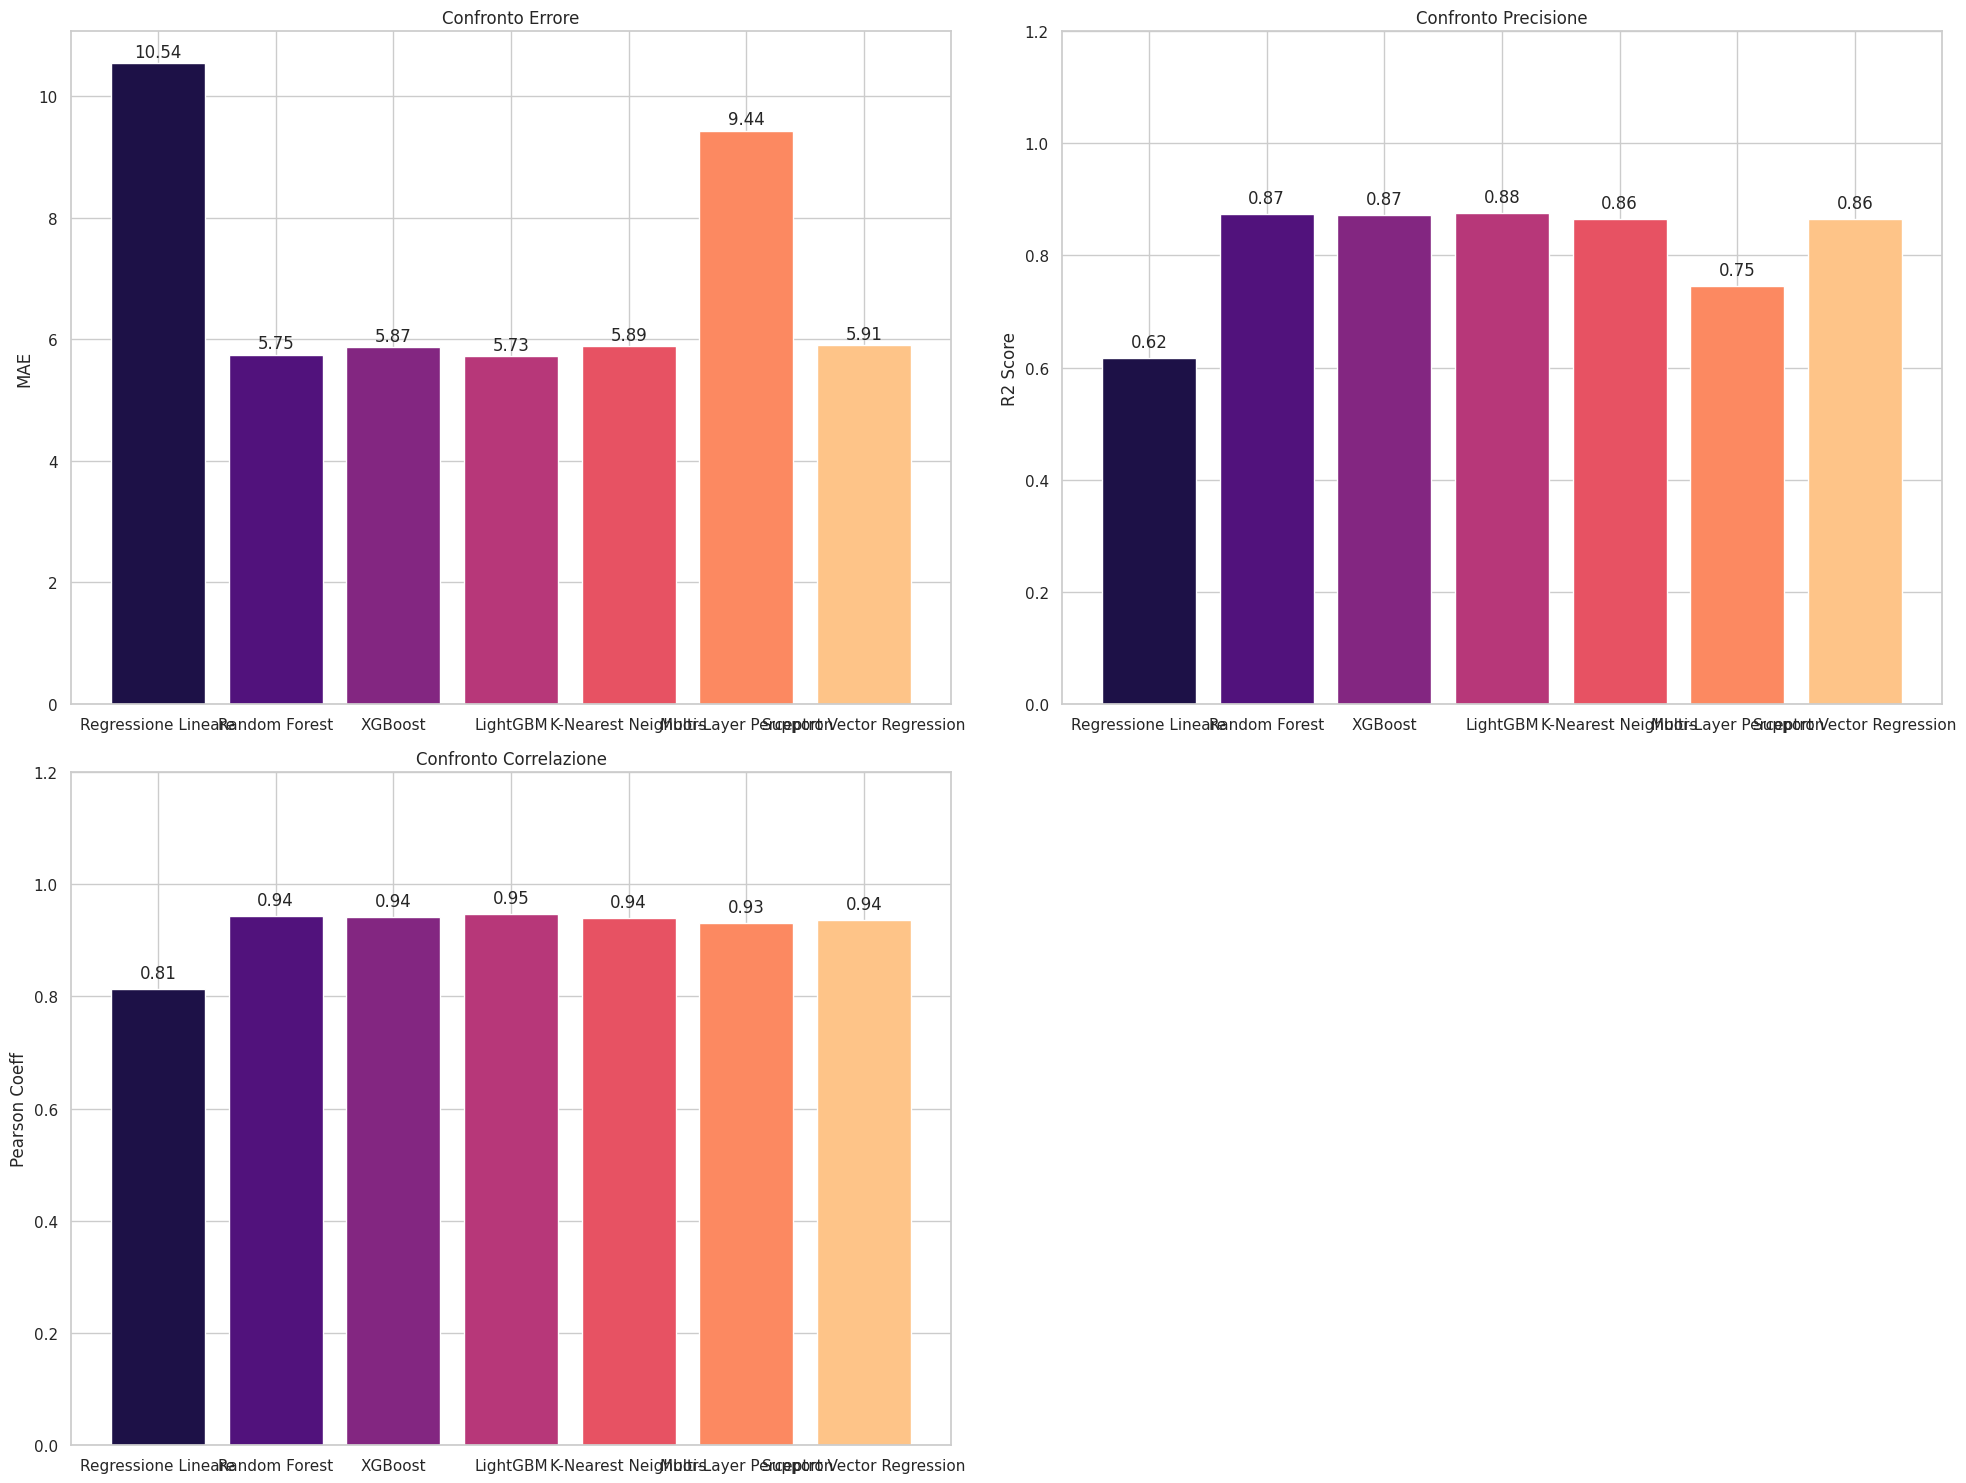

In [13]:
df_results = pd.DataFrame(dizionario).T

modelli = df_results.index
mae_values = df_results['MAE']
r2_values = df_results['R2']
coeff_values = df_results['Pearson']

x = np.arange(len(modelli))
colori = sns.color_palette("magma", len(modelli))

# 1. Grafico per il MAE
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
bars1 = plt.bar(x, mae_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('MAE')
plt.title('Confronto Errore')
# Aggiunge i numeri sopra le barre
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center')

# 2. Grafico per R2
plt.subplot(2, 2, 2)
bars2 = plt.bar(x, r2_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('R2 Score')
plt.title('Confronto Precisione')
plt.ylim(0, 1.2)
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center')

# 3. Grafico per il coefficiente di Pearson
plt.subplot(2, 2, 3)
bars3 = plt.bar(x, coeff_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Pearson Coeff')
plt.title('Confronto Correlazione')
plt.ylim(0, 1.2)
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center')

plt.tight_layout()
plt.show()

## XGBOOST OPTUNA

In [14]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    hyperparam = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000), #  (numero di alberi)
        'max_depth': trial.suggest_int('max_depth', 3, 10),  #passi che il modello fa per correggere gli errori
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**hyperparam)
    
    # Allenamento sul train
    model.fit(X_train, y_train)
    
    # Valutazione sul validation
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    
    return mae

# Eseguiamo l'ottimizzazione
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Migliori parametri:", study.best_params)

[I 2026-05-09 10:45:34,718] A new study created in memory with name: no-name-74b6e9b2-cd74-4619-b62f-5e581c178976
[I 2026-05-09 10:45:39,314] Trial 0 finished with value: 6.798481464385986 and parameters: {'n_estimators': 1256, 'max_depth': 10, 'learning_rate': 0.02635438066922089, 'subsample': 0.6705971504638337, 'colsample_bytree': 0.9248652862216469, 'min_child_weight': 2, 'gamma': 1.3162796084381186e-05}. Best is trial 0 with value: 6.798481464385986.
[I 2026-05-09 10:45:43,553] Trial 1 finished with value: 7.4543137550354 and parameters: {'n_estimators': 1355, 'max_depth': 10, 'learning_rate': 0.028180226663171094, 'subsample': 0.8811584336003508, 'colsample_bytree': 0.5711891019301869, 'min_child_weight': 1, 'gamma': 4.606472731303522e-05}. Best is trial 0 with value: 6.798481464385986.
[I 2026-05-09 10:45:45,528] Trial 2 finished with value: 5.531484127044678 and parameters: {'n_estimators': 1006, 'max_depth': 4, 'learning_rate': 0.020240320336591445, 'subsample': 0.714390207240

Migliori parametri: {'n_estimators': 1140, 'max_depth': 3, 'learning_rate': 0.019508186413211465, 'subsample': 0.6457503345006202, 'colsample_bytree': 0.865547869518328, 'min_child_weight': 9, 'gamma': 5.783871856295918e-05}


In [15]:
# 1. Creiamo il modello XGBoost
xgb_model_ott = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)

# 2. ALLENAMENTO
X_fit,y_fit = pd.concat([X_train, X_val]), pd.concat([y_train, y_val])
xgb_model_ott.fit(X_fit, y_fit) # Allenamento su train + validation per sfruttare tutti i dati

# 3. TEST
y_pred_xgb = xgb_model_ott.predict(X_test)

#4. STAMPA RISULTATI
print(f"--- Risultati XGBoost ---")
mae_xgb, r2_xgb, coeff_xgb = model_evaluation("XGBoost_Ottimizzato", y_test, y_pred_xgb)

#5. SALVATAGGIO MODELLO OTTIMIZZATO
model_path_xgb = "./xgb_model_ott.json"
xgb_model_ott.save_model(model_path_xgb)

print(f"Modello XGBoost salvato in: {model_path_xgb}")

--- Risultati XGBoost ---
--- Risultati XGBoost_Ottimizzato ---
MAE: 5.81
R²: 0.90
Pearson Coeff: 0.96
Modello XGBoost salvato in: ./xgb_model_ott.json


In [16]:
# 1. Visualizza la storia dell'ottimizzazione
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# 2. Visualizza l'importanza dei parametri
fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

# ONNX

In [17]:
#Per esportare il modello in ONNX, è necessario rimuovere i metadati dei nomi delle feature
xgb_model_ott.get_booster().feature_names = None

import onnxmltools
from skl2onnx.common.data_types import FloatTensorType

num_features = X_train.shape[1]
initial_type = [('float_input', FloatTensorType([None, num_features]))]

onnx_model = onnxmltools.convert_xgboost(xgb_model_ott, initial_types=initial_type, target_opset=13)

with open("./WebSite/xgb_model_ott.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

# TREELITE

In [18]:
import treelite, tl2cgen
import os
import contextlib

# 1. Converto
booster = xgb_model_ott.get_booster()
tl_model = treelite.frontend.from_xgboost(booster)

tl2cgen.generate_c_code(
    tl_model,
    dirpath="./model_c_src",
    params={'parallel_comp': 4},
    verbose=False
)

# 2. Compila
with open(os.devnull, 'wb') as devnull:
    with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
        tl2cgen.export_lib(
            tl_model,
            toolchain="gcc",
            libpath="./xgb_model_ott.so",
            params={'parallel_comp': 4},
            verbose=False
        )


[10:46:30] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0
[10:46:30] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0


[10:46:30] /project/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


# VALUTAZIONE DEI MODELLI

In [25]:
import time, os, tracemalloc, cProfile, pstats, gc
from memory_profiler import memory_usage
import onnxruntime as rt
import xgboost as xgb

def tecno_evaluation(model_path, tecno_type):
    n_iters = 1000
    print(f"\n--- ANALISI COMPLETA: {tecno_type.upper()} (su {n_iters} iterazioni) ---")

    load_times = []
    load_peaks = []

    # --- 1. DIMENSIONE FILE ---
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    
    # --- 2. TEMPO DI CARICAMENTO ---
    for n in range(n_iters):
        gc.collect()
        tracemalloc.start()
        start_load = time.perf_counter()
        
        if tecno_type == 'onnx':
            m = rt.InferenceSession(model_path)
        elif tecno_type == 'treelite':
            m = tl2cgen.Predictor(model_path)
        elif tecno_type == 'xgboost':
            m = xgb.XGBRegressor(); m.load_model(model_path)

        load_times.append((time.perf_counter() - start_load) * 1000)
        _, peak_load_ram = tracemalloc.get_traced_memory()
        load_peaks.append(peak_load_ram / 1024)
        tracemalloc.stop()

        if n < n_iters - 1: del m
        else: model_obj = m

    # --- 3. PREDIZIONE ---
    if tecno_type == 'xgboost':
        x_input = X_test.iloc[0:1]
        predict_fn = lambda: model_obj.predict(x_input)
    elif tecno_type == 'onnx':
        x_input = X_test.iloc[0:1].values.astype(np.float32)
        input_name = model_obj.get_inputs()[0].name
        predict_fn = lambda: model_obj.run(None, {input_name: x_input})
    elif tecno_type == 'treelite':
        x_input = tl2cgen.DMatrix(X_test.iloc[0:1].values.astype(np.float32))
        predict_fn = lambda: model_obj.predict(x_input)

    # --- 4. PROFILING CPU ---
    profiler = cProfile.Profile()
    profiler.enable()
    for n in range(100):
        predict_fn()
    profiler.disable()

    # --- 5. TEMPO DI ESECUZIONE ---
    inf_times = []
    for n in range(n_iters):
        t0 = time.perf_counter()
        predict_fn()
        inf_times.append((time.perf_counter() - t0) * 1000)

    # --- 6. USO RAM ---
    import psutil
    process = psutil.Process(os.getpid())
    ram_base = process.memory_info().rss / 1024
    def stress_test():
        for _ in range(n_iters): predict_fn()
    mem_use = memory_usage(stress_test, interval=0.01)
    peak_stress_ram = max(mem_use) * 1024
    delta_ram = max(0, peak_stress_ram - ram_base)

    dizionario_modelli[tecno_type] = {
        "latenza": np.mean(inf_times),
        "latenza_std": np.std(inf_times),
        "throughput": 1000/np.mean(inf_times),
        "ram_delta": delta_ram,
        "file_size": file_size,
        "tempo_di_caricamento": np.mean(load_times),
        "tempo_caricamento_std": np.std(load_times),
        "picco_RAM": np.mean(load_peaks)
    }

    # --- 7. OUTPUT REPORT ---
    print(f"Dimensione file: {file_size:.2f} MB")
    print(f"Tempo caricamento: {np.mean(load_times):.2f} ms (±{np.std(load_times):.2f} ms)")
    print(f"Latenza media: {np.mean(inf_times):.4f} ms (±{np.std(inf_times):.4f} ms)")
    print(f"Throughput: {1000/np.mean(inf_times):.2f} inf/sec")
    print(f"RAM Delta: {delta_ram:.2f} KB")
    print(f"RAM Picco: {np.mean(load_peaks):.2f} KB")

    # Stampa i risultati del profiling
    print("\n--- Top 5 Funzioni per tempo di esecuzione ---")
    stats = pstats.Stats(profiler).sort_stats('cumulative')
    stats.print_stats(5)


In [26]:
tecno_evaluation("./WebSite/xgb_model_ott.onnx", "onnx")


--- ANALISI COMPLETA: ONNX (su 1000 iterazioni) ---
Dimensione file: 0.53 MB
Tempo caricamento: 6.07 ms (±0.76 ms)
Latenza media: 0.0137 ms (±0.0026 ms)
Throughput: 73101.99 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 2.50 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         301 function calls in 0.002 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.002    0.000    0.002    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:278(run)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
      100    0.000    0.000    0.000    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:268(_validate_input)
      100    0.000    0.000    0.000  

In [21]:
tecno_evaluation("xgb_model_ott.so", "treelite")


--- ANALISI COMPLETA: TREELITE (su 1000 iterazioni) ---
Dimensione file: 0.52 MB
Tempo caricamento: 0.69 ms (±0.10 ms)
Latenza media: 0.1057 ms (±0.7958 ms)
Throughput: 9460.05 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 3.11 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         2311 function calls in 0.086 seconds

   Ordered by: cumulative time
   List reduced from 22 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.000    0.000    0.086    0.001 /tmp/ipykernel_7131/3831846440.py:52(<lambda>)
      100    0.084    0.001    0.086    0.001 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/tl2cgen/predictor.py:111(predict)
      100    0.000    0.000    0.001    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/numpy/ctypeslib/_ctypeslib.py:520(as_array)
      100    0.000    0.000    0.000    0.

In [22]:
tecno_evaluation("xgb_model_ott.json", "xgboost")


--- ANALISI COMPLETA: XGBOOST (su 1000 iterazioni) ---
Dimensione file: 1.24 MB
Tempo caricamento: 34.93 ms (±4.69 ms)
Latenza media: 2.9487 ms (±3.6121 ms)
Throughput: 339.14 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 16.74 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         247809 function calls (243109 primitive calls) in 0.599 seconds

   Ordered by: cumulative time
   List reduced from 297 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.000    0.000    0.599    0.006 /tmp/ipykernel_7131/3831846440.py:45(<lambda>)
  200/100    0.002    0.000    0.599    0.006 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/xgboost/core.py:732(inner_f)
      100    0.001    0.000    0.598    0.006 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/xgboost/sklearn.py:1401(predict)
      100    0.267    0.003   

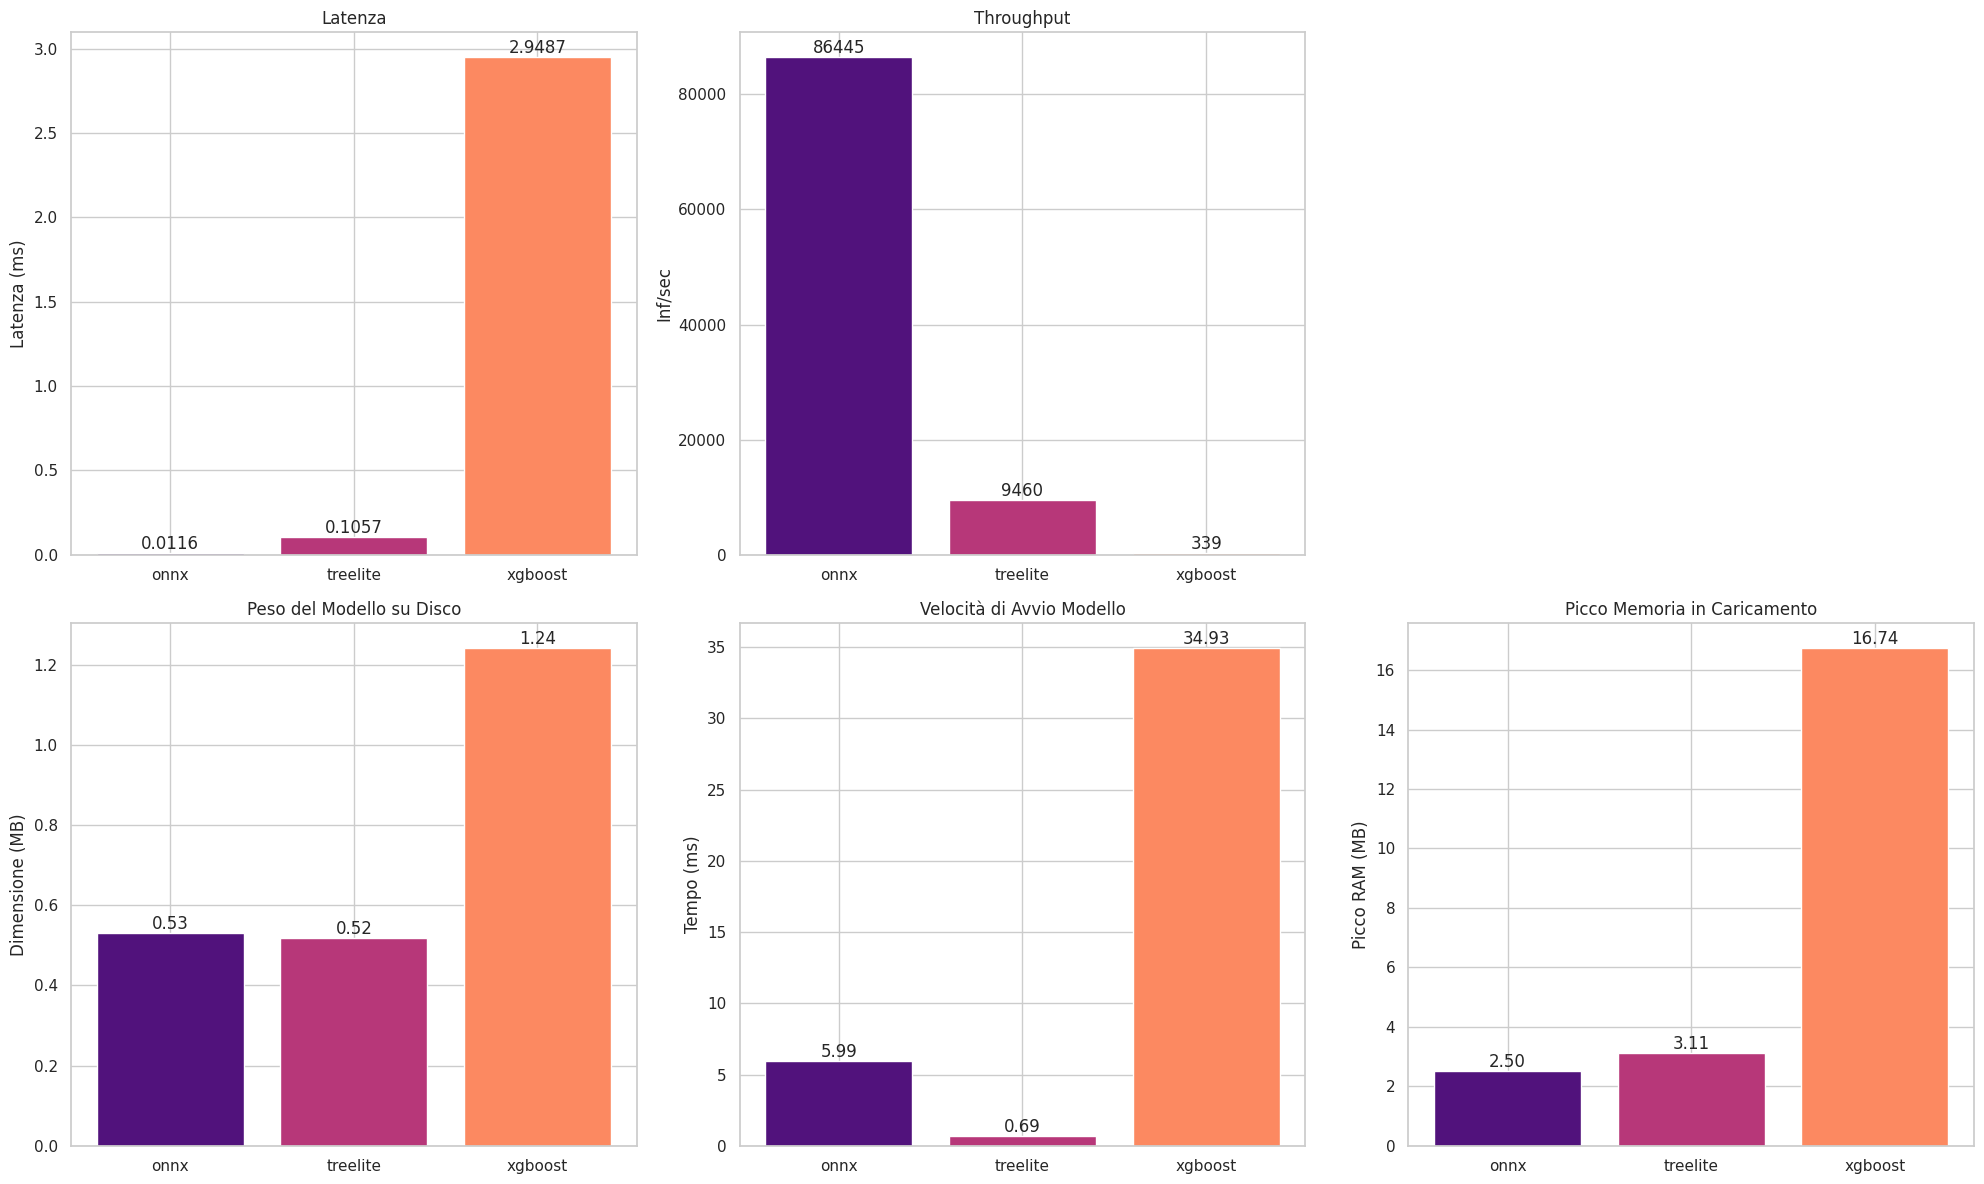

In [23]:
df_results = pd.DataFrame(dizionario_modelli).T

modelli = df_results.index
latenza_values = df_results['latenza']
throughput_values = df_results['throughput']
ram_delta_values = df_results['ram_delta']
file_size_values = df_results['file_size']
tempo_di_caricamento_values = df_results['tempo_di_caricamento']
picco_RAM_values = df_results['picco_RAM']

x = np.arange(len(modelli))
colori = sns.color_palette("magma", len(modelli))

plt.figure(figsize=(20, 12))

# 1. Latenza
plt.subplot(2, 3, 1)
bars1 = plt.bar(x, latenza_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Latenza (ms)')
plt.title('Latenza')
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom')

# 2. Throughput
plt.subplot(2, 3, 2)
bars2 = plt.bar(x, throughput_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Inf/sec')
plt.title('Throughput')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom')

# 4. File Size
plt.subplot(2, 3, 4)
bars4 = plt.bar(x, file_size_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Dimensione (MB)')
plt.title('Peso del Modello su Disco')
for bar in bars4:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

# 5. Tempo di Caricamento
plt.subplot(2, 3, 5)
bars5 = plt.bar(x, tempo_di_caricamento_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Tempo (ms)')
plt.title('Velocità di Avvio Modello')
for bar in bars5:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

# 6. Picco RAM
plt.subplot(2, 3, 6)
bars6 = plt.bar(x, picco_RAM_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Picco RAM (MB)')
plt.title('Picco Memoria in Caricamento')
for bar in bars6:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

#plt.savefig('grafici.png', dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()